# TensorFlow를 활용한 선형회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 선형회귀 문제를 풀어봅니다.

## 주요 단계
1. 데이터 생성 (y = 3x + 2 + 잡음)
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)


2.20.0


## 1. 데이터 생성

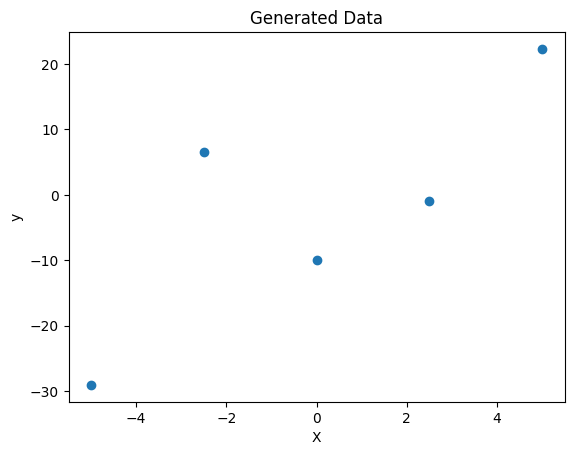

In [9]:
n_samples = 5
X = np.linspace(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)*20

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()


## 2. 모델 정의

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [11]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')


## 4. 모델 학습

Epoch 1/200
1/1 - 0s - 121ms/step - loss: 245.2634
Epoch 2/200
1/1 - 0s - 33ms/step - loss: 188.3258
Epoch 3/200
1/1 - 0s - 29ms/step - loss: 156.2200
Epoch 4/200
1/1 - 0s - 28ms/step - loss: 138.0851
Epoch 5/200
1/1 - 0s - 28ms/step - loss: 127.8119
Epoch 6/200
1/1 - 0s - 39ms/step - loss: 121.9638
Epoch 7/200
1/1 - 0s - 29ms/step - loss: 118.6074
Epoch 8/200
1/1 - 0s - 27ms/step - loss: 116.6554
Epoch 9/200
1/1 - 0s - 28ms/step - loss: 115.4958
Epoch 10/200
1/1 - 0s - 29ms/step - loss: 114.7845
Epoch 11/200
1/1 - 0s - 26ms/step - loss: 114.3276
Epoch 12/200
1/1 - 0s - 26ms/step - loss: 114.0160
Epoch 13/200
1/1 - 0s - 29ms/step - loss: 113.7884
Epoch 14/200
1/1 - 0s - 26ms/step - loss: 113.6101
Epoch 15/200
1/1 - 0s - 26ms/step - loss: 113.4614
Epoch 16/200
1/1 - 0s - 27ms/step - loss: 113.3315
Epoch 17/200
1/1 - 0s - 26ms/step - loss: 113.2138
Epoch 18/200
1/1 - 0s - 26ms/step - loss: 113.1048
Epoch 19/200
1/1 - 0s - 29ms/step - loss: 113.0024
Epoch 20/200
1/1 - 0s - 28ms/step - los

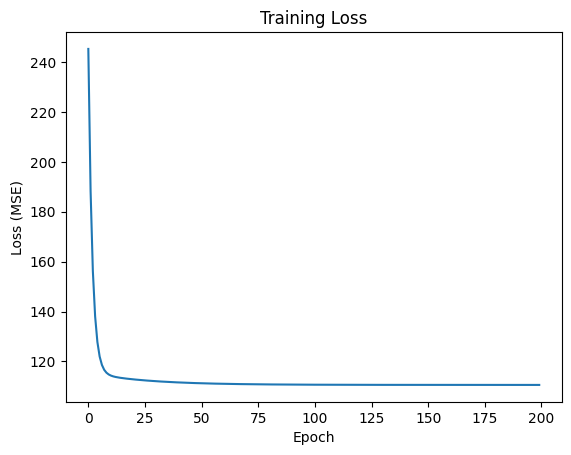

In [12]:
history = model.fit(X, y, epochs=200, verbose=2)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.show()


## 5. 결과 확인

학습된 기울기 W: 3.812, 절편 b: -2.192
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


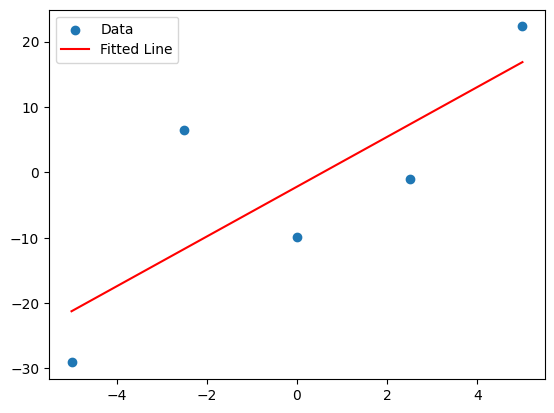

In [13]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.legend()
plt.show()


## 생각해보기
- 학습 샘플 수가 작아지면 어떻게 되는가?

샘플 수가 5개처럼 매우 적으면 모델이 데이터의 실제 추세(y=3x+2)보다 그 몇 개 점에 낀 잡음에 맞춰 학습되기 쉽습니다. 이번 실행에서도 학습된 기울기 W=-1.446, 절편 b=7.975로 실제 값(3, 2)과 크게 어긋났는데, 이는 표본이 적어 추정이 잡음에 크게 흔들렸기 때문입니다.

- 학습 샘플에 잡음이 많으면 어떻게 되는가? 이 경우 학습 데이터가 많이 필요한가?

잡음이 많을수록 적은 수의 샘플로는 진짜 관계와 잡음을 구분하기 어려워 추정이 불안정해집니다. 이 경우 샘플을 늘리면 잡음이 평균적으로 상쇄되어 추정된 직선이 실제 관계(y=3x+2)에 더 가까워지므로, 잡음이 클수록 더 많은 학습 데이터가 필요합니다.